# Gen-Aware Mass Diagnostic Ntuple Plots

MC-only diagnostics for the `mass_diagnostic_ntuple` output. The notebook compares the current corrected AK8 quantities to the default NanoAOD quantities on the same reco-selected rows, using the saved gen match information for response and resolution checks.

In [ ]:
from __future__ import annotations

import os
from pathlib import Path
import pickle
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-zjet")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
import mplhep as hep
from IPython.display import display

cwd = Path.cwd().resolve()
if (cwd / "src" / "zjet_corrections").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src" / "zjet_corrections").exists():
    REPO_ROOT = cwd.parent
else:
    REPO_ROOT = Path("/mnt/extra/wsLinux/zjet_corrections")

sys.path.insert(0, str(REPO_ROOT / "src"))
from zjet_corrections.hist_utils import util_binning

hep.style.use([
    hep.style.CMS,
    {
        "figure.figsize": (8, 6),
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    },
])


In [ ]:
NTUPLE_PATH = REPO_ROOT / "outputs" / "mass_diagnostic_ntuple_pythia_2016.pkl"
DATA_NTUPLE_PATH = REPO_ROOT / "outputs" / "mass_diagnostic_ntuple_data_2016.pkl"
PLOT_DIR = REPO_ROOT / "outputs" / "mass_diagnostic_ntuple_plots"
ERA = "2016"
PLOT_DPI = 160

PLOT_DIR.mkdir(parents=True, exist_ok=True)
_SAVED_FIGURES: list[Path] = []

binning = util_binning()
PT_EDGES = np.asarray([200.0, 290.0, 400.0, 13000.0])
MASS_RECO_EDGES = np.asarray(binning.mreco_axis.edges, dtype=float)
MASS_GEN_EDGES = np.asarray(binning.mgen_axis.edges, dtype=float)

# Coarser mass edges from hist_utils.py's response-style mass-binning block.
# The final util_binning axes are very fine diagnostic axes; those make the
# flattened response display unreadably granular.
RESPONSE_MASS_GEN_EDGES = np.asarray([
    0.0, 10.0, 20.0, 30.0, 50.0, 70.0, 90.0, 110.0,
    130.0, 150.0, 170.0, 200.0, 1000.0,
], dtype=float)
RESPONSE_MASS_RECO_EDGES = np.asarray([
    0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0,
    50.0, 60.0, 70.0, 80.0, 90.0, 100.0, 110.0,
    120.0, 130.0, 140.0, 150.0, 160.0, 170.0, 185.0,
    200.0, 215.0, 1000.0,
], dtype=float)
PURITY_MASS_EDGES = RESPONSE_MASS_GEN_EDGES
MASS_DISPLAY_RANGE = (0.0, 200.0)
DATAMC_PT_EDGES = np.asarray([200.0, 230.0, 260.0, 290.0, 330.0, 400.0, 500.0, 650.0, 800.0, 1000.0, 1300.0, 2000.0, 3500.0], dtype=float)

PT_LABELS = [
    f"{PT_EDGES[i]:.0f}-{PT_EDGES[i + 1]:.0f} GeV" if PT_EDGES[i + 1] < 1000 else f"> {PT_EDGES[i]:.0f} GeV"
    for i in range(len(PT_EDGES) - 1)
]

print(f"Repo root: {REPO_ROOT}")
print(f"Input: {NTUPLE_PATH}")
print(f"Data input: {DATA_NTUPLE_PATH if DATA_NTUPLE_PATH.exists() else 'not found'}")
print(f"Plot directory: {PLOT_DIR}")


Repo root: /mnt/extra/wsLinux/zjet_corrections
Input: /mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_pythia_2016.pkl
Data input: /mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_data_2016.pkl
Plot directory: /mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots


In [ ]:
def accumulator_to_numpy(ntuple):
    cols = {}
    for name, value in ntuple.items():
        arr = value.value if hasattr(value, "value") else value
        arr = np.asarray(arr)
        if arr.dtype.kind == "S":
            arr = arr.astype(str)
        cols[name] = arr
    return cols

REQUIRED_COLUMNS = [
    "weight", "pt", "mass", "msoftdrop", "pt_nanoaod", "mass_nanoaod", "msoftdrop_nanoaod",
    "pt_raw", "mass_raw", "msoftdrop_raw", "msoftdrop_raw_fatjet",
    "gen_pt", "gen_mass", "gen_msoftdrop", "reco_gen_dr",
    "has_gen_match", "passes_gen_selection", "passes_both", "dataset", "channel", "systematic",
]

def load_reco_jet_ntuple(path):
    with Path(path).open("rb") as f:
        loaded = pickle.load(f)
    if "reco_jet_ntuple" not in loaded:
        raise KeyError(f"{path} is missing 'reco_jet_ntuple'. Run mass_diagnostic_ntuple mode first.")
    cols = accumulator_to_numpy(loaded["reco_jet_ntuple"])
    missing = sorted(set(REQUIRED_COLUMNS) - set(cols))
    if missing:
        raise KeyError(f"{path} is missing required columns: {missing}")
    lengths_local = pd.Series({name: len(values) for name, values in cols.items()}, name="length")
    if lengths_local.nunique() != 1:
        display(lengths_local.sort_values())
        raise ValueError(f"{path} columns do not all have the same length.")
    return loaded, cols, lengths_local

out, nt, lengths = load_reco_jet_ntuple(NTUPLE_PATH)

data_out = None
data_nt = None
data_lengths = None
if DATA_NTUPLE_PATH.exists():
    data_out, data_nt, data_lengths = load_reco_jet_ntuple(DATA_NTUPLE_PATH)



nrows = int(lengths.iloc[0])
matched = nt["has_gen_match"].astype(bool) & np.isfinite(nt["reco_gen_dr"]) & (nt["reco_gen_dr"] < 0.4)
gen_selected = nt["passes_gen_selection"].astype(bool)
passes_both = nt["passes_both"].astype(bool)
physics_mask = passes_both
response_base = physics_mask & matched

summary = pd.DataFrame(
    {
        "quantity": ["rows", "has_gen_match", "passes_gen_selection", "passes_both", "response_base"],
        "count": [nrows, int(matched.sum()), int(gen_selected.sum()), int(passes_both.sum()), int(response_base.sum())],
    }
)
summary["fraction"] = summary["count"] / nrows

display(summary)
display(lengths.to_frame().T.rename(index={"length": "mc"}))
if data_nt is not None:
    display(pd.DataFrame({"quantity": ["data rows"], "count": [int(data_lengths.iloc[0])] }))
    display(data_lengths.to_frame().T.rename(index={"length": "data"}))
else:
    print(f"No data ntuple found at {DATA_NTUPLE_PATH}; Data/MC cells will be skipped.")


,quantity,count,fraction
0,rows,758887,1.000000
1,has_gen_match,740357,0.975583
2,passes_gen_selection,722986,0.952693
3,passes_both,722986,0.952693
4,response_base,722986,0.952693


,weight,pt,mass,msoftdrop,eta,phi,rapidity,pt_nanoaod,mass_nanoaod,msoftdrop_nanoaod,...,reco_gen_dr,event,run,luminosityBlock,has_gen_match,passes_gen_selection,passes_both,dataset,channel,systematic
mc,758887,758887,758887,758887,758887,758887,758887,758887,758887,758887,...,758887,758887,758887,758887,758887,758887,758887,758887,758887,758887


,dataset,postprocess_scale
0,pythia_UL16NanoAODv9_HT-100to200,0.369125
1,pythia_UL16NanoAODv9_HT-1200to2500,0.001460
2,pythia_UL16NanoAODv9_HT-200to400,0.149782
3,pythia_UL16NanoAODv9_HT-2500toInf,0.000095
4,pythia_UL16NanoAODv9_HT-400to600,0.045798
5,pythia_UL16NanoAODv9_HT-600to800,0.012063
6,pythia_UL16NanoAODv9_HT-800to1200,0.005157


,quantity,count
0,data rows,44108


,weight,pt,mass,msoftdrop,eta,phi,rapidity,pt_nanoaod,mass_nanoaod,msoftdrop_nanoaod,...,reco_gen_dr,event,run,luminosityBlock,has_gen_match,passes_gen_selection,passes_both,dataset,channel,systematic
data,44108,44108,44108,44108,44108,44108,44108,44108,44108,44108,...,44108,44108,44108,44108,44108,44108,44108,44108,44108,44108


In [ ]:
def finite_positive(*arrays):
    mask = np.ones(nrows, dtype=bool)
    for arr in arrays:
        arr = np.asarray(arr)
        mask &= np.isfinite(arr) & (arr > 0)
    return mask


def finite_all(*arrays):
    mask = np.ones(nrows, dtype=bool)
    for arr in arrays:
        mask &= np.isfinite(arr)
    return mask


def weights_for(mask):
    return np.asarray(nt["weight"], dtype=float)[mask]


def safe_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full_like(num, np.nan, dtype=float)
    good = np.isfinite(num) & np.isfinite(den) & (den != 0)
    out[good] = num[good] / den[good]
    return out


def weighted_quantile(values, quantiles, sample_weight=None):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    good = np.isfinite(values)
    values = values[good]
    if sample_weight is None:
        if values.size == 0:
            return np.full_like(quantiles, np.nan, dtype=float)
        return np.quantile(values, quantiles)
    weights = np.asarray(sample_weight, dtype=float)[good]
    good_w = np.isfinite(weights) & (weights > 0)
    values = values[good_w]
    weights = weights[good_w]
    if values.size == 0 or weights.sum() <= 0:
        return np.full_like(quantiles, np.nan, dtype=float)
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cdf = np.cumsum(weights) - 0.5 * weights
    cdf /= np.sum(weights)
    return np.interp(quantiles, cdf, values)


def add_cms_label(ax, rlabel=None):
    hep.cms.label(data=True, year=None, lumi=None, com=None, rlabel=rlabel, ax=ax)


def save_show(fig, name):
    path = PLOT_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, dpi=PLOT_DPI, bbox_inches="tight")
    _SAVED_FIGURES.append(path)
    display(fig)
    plt.close(fig)
    return path


def hist_step(ax, values, bins, mask, label, weights=None, density=True, **kwargs):
    values = np.asarray(values, dtype=float)
    m = mask & np.isfinite(values)
    if weights is None:
        w = weights_for(m)
    else:
        w = np.asarray(weights, dtype=float)[m]
    ax.hist(values[m], bins=bins, weights=w, histtype="step", density=density, label=label, linewidth=1.8, **kwargs)
    return m.sum()


def plot_weighted_2d(ax, x, y, xedges, yedges, mask, weights=None, cmap="viridis", log=True, vmin=None, vmax=None):
    m = mask & np.isfinite(x) & np.isfinite(y)
    w = weights_for(m) if weights is None else np.asarray(weights, dtype=float)[m]
    counts, _, _ = np.histogram2d(np.asarray(x)[m], np.asarray(y)[m], bins=[xedges, yedges], weights=w)
    plot_values = counts.T
    if log:
        positive = plot_values[plot_values > 0]
        if positive.size:
            norm = LogNorm(vmin=vmin or max(float(positive.min()), 1e-12), vmax=vmax or float(positive.max()))
            plot_values = np.ma.masked_where(plot_values <= 0, plot_values)
        else:
            norm = None
    else:
        norm = None
    mesh = ax.pcolormesh(xedges, yedges, plot_values, cmap=cmap, norm=norm, shading="auto")
    return mesh, counts


,dataset,channel,rows
11,pythia_UL16NanoAODv9_HT-100to200,ee,5396
10,pythia_UL16NanoAODv9_HT-100to200,mm,11446
9,pythia_UL16NanoAODv9_HT-1200to2500,ee,24309
8,pythia_UL16NanoAODv9_HT-1200to2500,mm,34555
4,pythia_UL16NanoAODv9_HT-200to400,ee,71068
0,pythia_UL16NanoAODv9_HT-200to400,mm,142010
13,pythia_UL16NanoAODv9_HT-2500toInf,ee,2049
12,pythia_UL16NanoAODv9_HT-2500toInf,mm,2641
5,pythia_UL16NanoAODv9_HT-400to600,ee,64193
1,pythia_UL16NanoAODv9_HT-400to600,mm,120548


,flag,fraction,count
0,has_gen_match,0.975583,740357
1,passes_gen_selection,0.952693,722986
2,passes_both,0.952693,722986
3,response_base,0.952693,722986


,column,finite among matched
0,gen_pt,1.0
1,gen_mass,1.0
2,gen_msoftdrop,1.0
3,reco_gen_dr,1.0


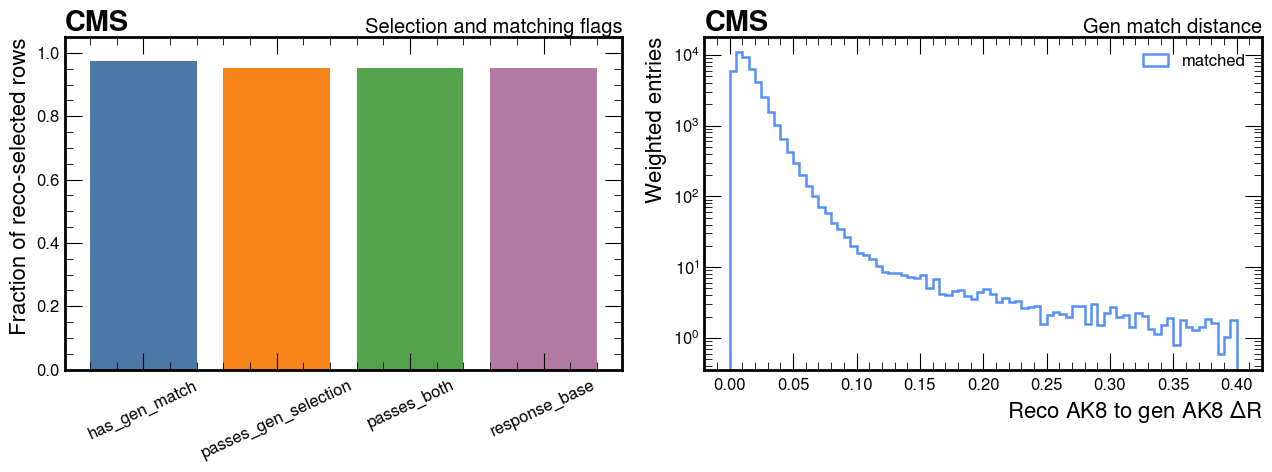

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/sanity_flags_and_match_dr.png')

In [ ]:
dataset_channel_counts = (
    pd.DataFrame({"dataset": nt["dataset"], "channel": nt["channel"]})
    .value_counts(["dataset", "channel"])
    .rename("rows")
    .reset_index()
    .sort_values(["dataset", "channel"])
)
flag_summary = pd.DataFrame(
    {
        "flag": ["has_gen_match", "passes_gen_selection", "passes_both", "response_base"],
        "fraction": [matched.mean(), gen_selected.mean(), passes_both.mean(), response_base.mean()],
        "count": [matched.sum(), gen_selected.sum(), passes_both.sum(), response_base.sum()],
    }
)
finite_gen_summary = pd.DataFrame(
    {
        "column": ["gen_pt", "gen_mass", "gen_msoftdrop", "reco_gen_dr"],
        "finite among matched": [np.isfinite(nt[c][matched]).mean() for c in ["gen_pt", "gen_mass", "gen_msoftdrop", "reco_gen_dr"]],
    }
)

display(dataset_channel_counts)
display(flag_summary)
display(finite_gen_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(flag_summary["flag"], flag_summary["fraction"], color=["#4C78A8", "#F58518", "#54A24B", "#B279A2"])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("Fraction of reco-selected rows")
axes[0].tick_params(axis="x", rotation=25)
add_cms_label(axes[0], rlabel="Selection and matching flags")

hist_step(axes[1], nt["reco_gen_dr"], np.linspace(0, 0.4, 81), matched, label="matched", density=False)
axes[1].set_xlabel(r"Reco AK8 to gen AK8 $\Delta R$")
axes[1].set_ylabel("Weighted entries")
axes[1].set_yscale("log")
axes[1].legend()
add_cms_label(axes[1], rlabel="Gen match distance")
save_show(fig, "sanity_flags_and_match_dr")


## Data/MC Reco Shape Comparisons

Area-normalized data-vs-Pythia comparisons for reco-selected leading AK8 jets. The left panel uses the default NanoAOD value and the right panel uses the current corrected value.

/tmp/ipykernel_48412/3407772794.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


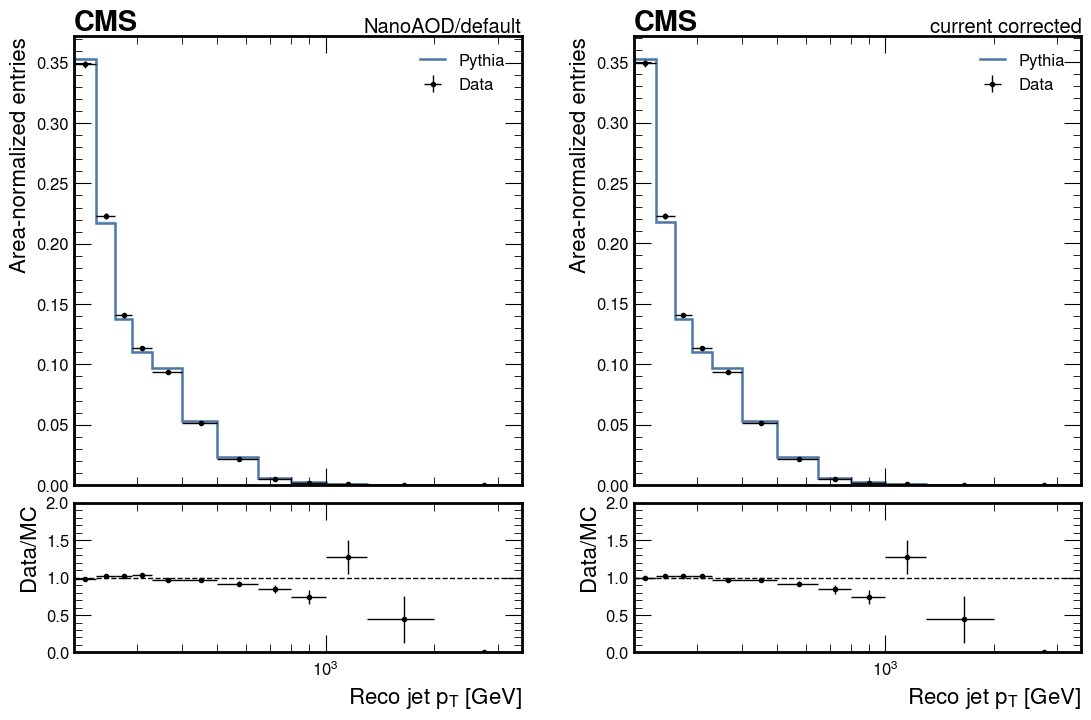

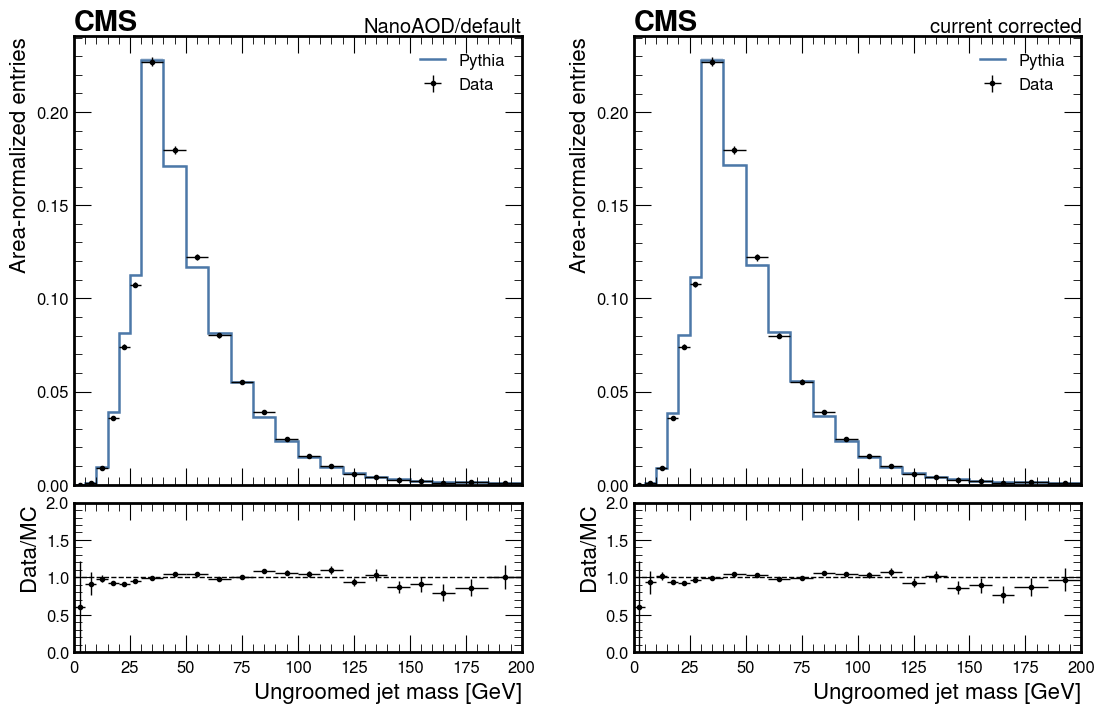

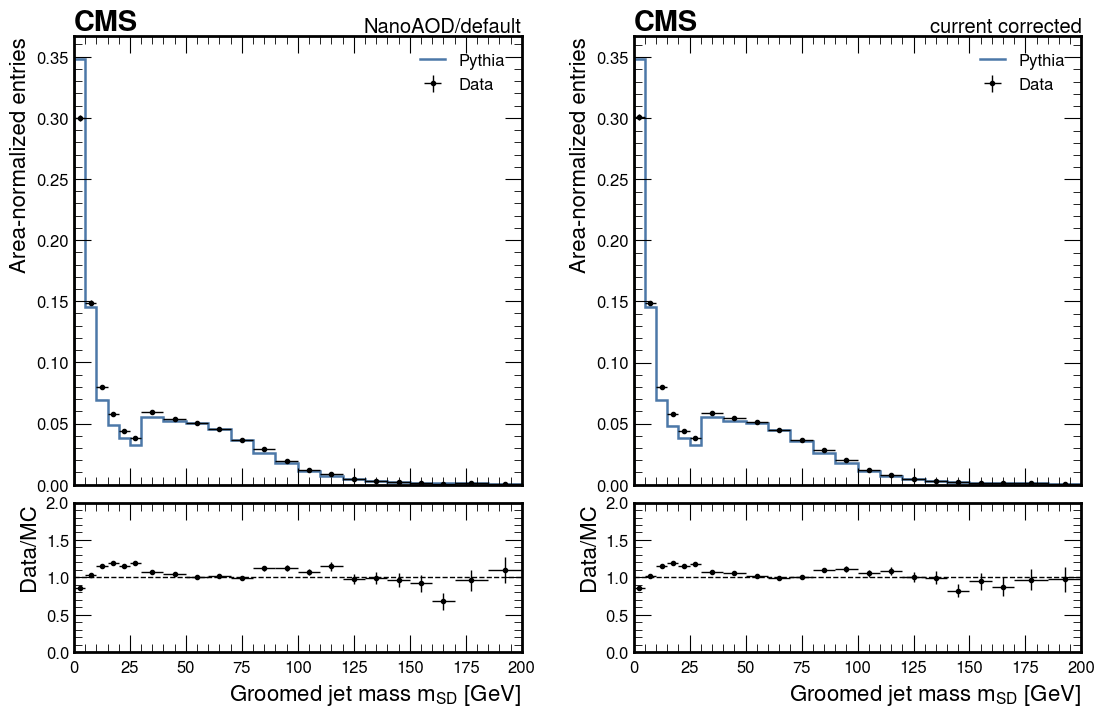

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/datamc_groomed_mass_nanoaod_vs_corrected.png')

In [ ]:
def _hist_counts(values, bins, weights=None, mask=None, density=True):
    values = np.asarray(values, dtype=float)
    local_mask = np.isfinite(values)
    if mask is not None:
        local_mask &= np.asarray(mask, dtype=bool)
    if weights is None:
        w = np.ones(local_mask.sum(), dtype=float)
    else:
        w = np.asarray(weights, dtype=float)[local_mask]
    counts, _ = np.histogram(values[local_mask], bins=bins, weights=w)
    sumw2, _ = np.histogram(values[local_mask], bins=bins, weights=w * w)
    if density:
        total = counts.sum()
        if total > 0:
            counts = counts / total
            sumw2 = sumw2 / (total * total)
    return counts, np.sqrt(sumw2)


def _plot_datamc_step_with_ratio(ax_top, ax_ratio, data_values, mc_values, bins, xlabel, rlabel, data_mask=None, mc_mask=None):
    data_counts, data_err = _hist_counts(data_values, bins, weights=None, mask=data_mask, density=True)
    mc_counts, mc_err = _hist_counts(mc_values, bins, weights=nt["weight"], mask=mc_mask, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])
    widths = np.diff(bins)

    ax_top.errorbar(centers, data_counts, yerr=data_err, xerr=0.5 * widths, fmt="o", color="black", markersize=3.0, linewidth=1.0, label="Data")
    ax_top.stairs(mc_counts, bins, color="#4C78A8", linewidth=1.8, label="Pythia")
    ax_top.fill_between(bins, np.r_[mc_counts - mc_err, (mc_counts - mc_err)[-1]], np.r_[mc_counts + mc_err, (mc_counts + mc_err)[-1]], step="post", color="#4C78A8", alpha=0.18, linewidth=0)
    ax_top.set_ylabel("Area-normalized entries")
    ax_top.legend()
    add_cms_label(ax_top, rlabel=rlabel)

    ratio = np.divide(data_counts, mc_counts, out=np.full_like(data_counts, np.nan, dtype=float), where=mc_counts > 0)
    ratio_err = np.divide(data_err, mc_counts, out=np.full_like(data_err, np.nan, dtype=float), where=mc_counts > 0)
    ax_ratio.axhline(1.0, color="black", linestyle="--", linewidth=1.0)
    ax_ratio.errorbar(centers, ratio, yerr=ratio_err, xerr=0.5 * widths, fmt="o", color="black", markersize=3.0, linewidth=1.0)
    ax_ratio.set_ylabel("Data/MC")
    ax_ratio.set_xlabel(xlabel)
    ax_ratio.set_ylim(0.0, 2.0)


def plot_datamc_before_after(var_nanoaod, var_corrected, bins, xlabel, name, xlim=None, logx=False):
    if data_nt is None:
        print(f"Skipping {name}: DATA_NTUPLE_PATH does not exist: {DATA_NTUPLE_PATH}")
        return None
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex="col", gridspec_kw={"height_ratios": [3.0, 1.0], "hspace": 0.06, "wspace": 0.25})
    specs = [
        (var_nanoaod, "NanoAOD/default"),
        (var_corrected, "current corrected"),
    ]
    for col, (var, label) in enumerate(specs):
        data_values = data_nt[var]
        mc_values = nt[var]
        data_mask = np.isfinite(data_values) & (data_values > 0)
        mc_mask = np.isfinite(mc_values) & (mc_values > 0)
        _plot_datamc_step_with_ratio(
            axes[0, col],
            axes[1, col],
            data_values,
            mc_values,
            bins,
            xlabel=xlabel,
            rlabel=label,
            data_mask=data_mask,
            mc_mask=mc_mask,
        )
        if xlim is not None:
            axes[0, col].set_xlim(*xlim)
            axes[1, col].set_xlim(*xlim)
        if logx:
            axes[0, col].set_xscale("log")
            axes[1, col].set_xscale("log")
        axes[0, col].tick_params(labelbottom=False)
    return save_show(fig, name)

plot_datamc_before_after("pt_nanoaod", "pt", DATAMC_PT_EDGES, r"Reco jet $p_T$ [GeV]", "datamc_reco_pt_nanoaod_vs_corrected", xlim=(200, 3500), logx=True)
plot_datamc_before_after("mass_nanoaod", "mass", RESPONSE_MASS_RECO_EDGES, "Ungroomed jet mass [GeV]", "datamc_ungroomed_mass_nanoaod_vs_corrected", xlim=MASS_DISPLAY_RANGE)
plot_datamc_before_after("msoftdrop_nanoaod", "msoftdrop", RESPONSE_MASS_RECO_EDGES, r"Groomed jet mass $m_{SD}$ [GeV]", "datamc_groomed_mass_nanoaod_vs_corrected", xlim=MASS_DISPLAY_RANGE)


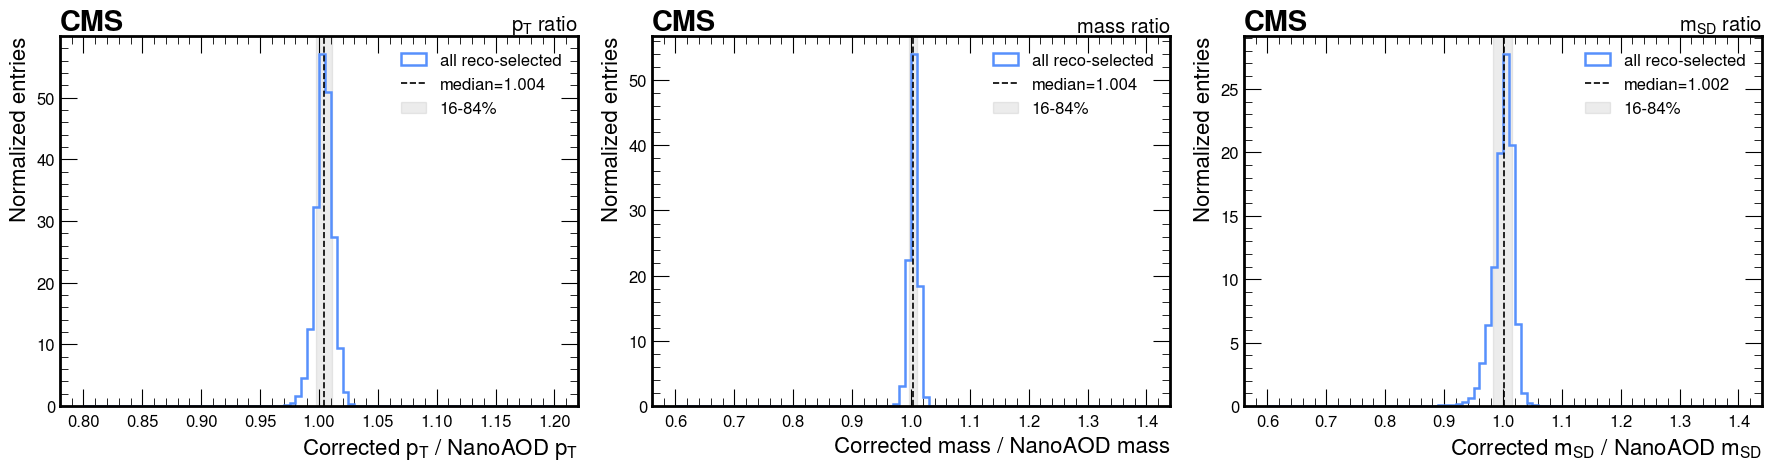

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/corrected_over_nanoaod_ratios.png')

In [ ]:
ratio_specs = [
    ("pt", "pt_nanoaod", r"Corrected $p_T$ / NanoAOD $p_T$", np.linspace(0.8, 1.2, 81), r"$p_T$ ratio"),
    ("mass", "mass_nanoaod", r"Corrected mass / NanoAOD mass", np.linspace(0.6, 1.4, 81), "mass ratio"),
    ("msoftdrop", "msoftdrop_nanoaod", r"Corrected $m_{SD}$ / NanoAOD $m_{SD}$", np.linspace(0.6, 1.4, 81), r"$m_{SD}$ ratio"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (num, den, xlabel, bins, rlabel) in zip(axes, ratio_specs):
    ratio = safe_ratio(nt[num], nt[den])
    mask = finite_positive(nt[num], nt[den])
    hist_step(ax, ratio, bins, mask, label="all reco-selected", density=True)
    q16, q50, q84 = weighted_quantile(ratio[mask], [0.16, 0.50, 0.84], weights_for(mask))
    ax.axvline(q50, color="black", linestyle="--", linewidth=1.2, label=f"median={q50:.3f}")
    ax.axvspan(q16, q84, color="gray", alpha=0.15, label="16-84%")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized entries")
    ax.legend()
    add_cms_label(ax, rlabel=rlabel)
save_show(fig, "corrected_over_nanoaod_ratios")


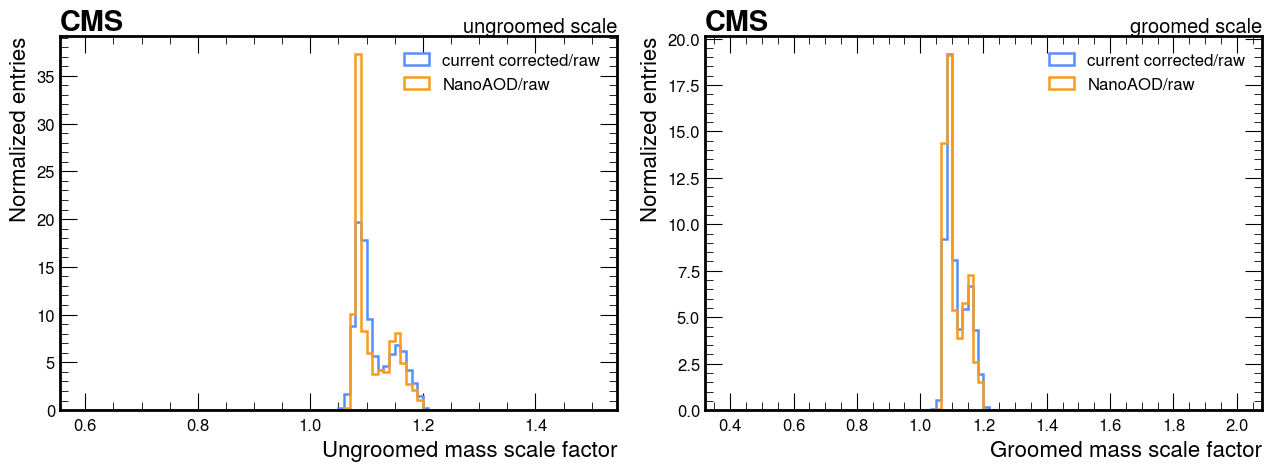

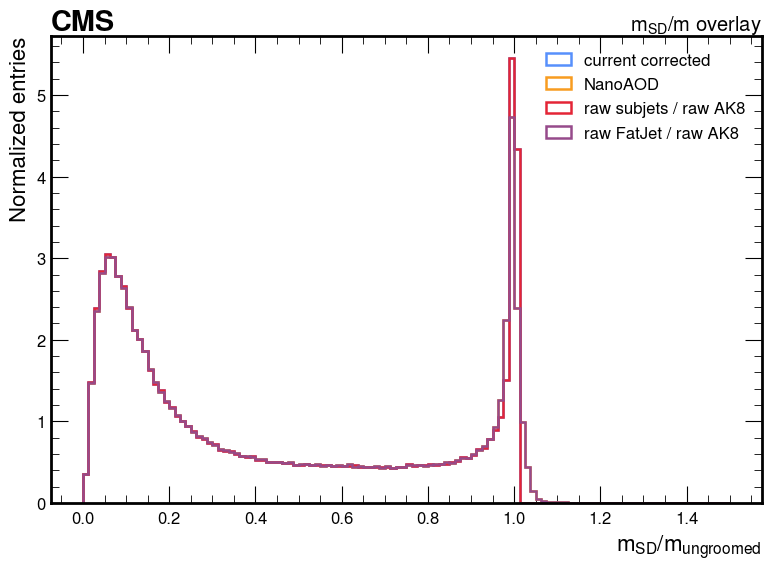

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/groomed_over_ungroomed_mass_ratio_overlay.png')

In [ ]:
scale_specs = [
    (safe_ratio(nt["mass"], nt["mass_raw"]), safe_ratio(nt["mass_nanoaod"], nt["mass_raw"]), finite_positive(nt["mass"], nt["mass_nanoaod"], nt["mass_raw"]), r"Ungroomed mass scale factor", np.linspace(0.6, 1.5, 91), "ungroomed scale"),
    (safe_ratio(nt["msoftdrop"], nt["msoftdrop_raw"]), safe_ratio(nt["msoftdrop_nanoaod"], nt["msoftdrop_raw_fatjet"]), finite_positive(nt["msoftdrop"], nt["msoftdrop_raw"], nt["msoftdrop_nanoaod"], nt["msoftdrop_raw_fatjet"]), r"Groomed mass scale factor", np.linspace(0.4, 2.0, 97), "groomed scale"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (corr_sf, nano_sf, mask, xlabel, bins, rlabel) in zip(axes, scale_specs):
    hist_step(ax, corr_sf, bins, mask, label="current corrected/raw", density=True)
    hist_step(ax, nano_sf, bins, mask, label="NanoAOD/raw", density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Normalized entries")
    ax.legend()
    add_cms_label(ax, rlabel=rlabel)
save_show(fig, "mass_scale_factor_comparison")

fig, ax = plt.subplots(figsize=(8, 6))
ratio_items = [
    (safe_ratio(nt["msoftdrop"], nt["mass"]), finite_positive(nt["msoftdrop"], nt["mass"]), "current corrected"),
    (safe_ratio(nt["msoftdrop_nanoaod"], nt["mass_nanoaod"]), finite_positive(nt["msoftdrop_nanoaod"], nt["mass_nanoaod"]), "NanoAOD"),
    (safe_ratio(nt["msoftdrop_raw"], nt["mass_raw"]), finite_positive(nt["msoftdrop_raw"], nt["mass_raw"]), "raw subjets / raw AK8"),
    (safe_ratio(nt["msoftdrop_raw_fatjet"], nt["mass_raw"]), finite_positive(nt["msoftdrop_raw_fatjet"], nt["mass_raw"]), "raw FatJet / raw AK8"),
]
for values, mask, label in ratio_items:
    hist_step(ax, values, np.linspace(0, 1.5, 121), mask, label=label, density=True)
ax.set_xlabel(r"$m_{SD} / m_{ungroomed}$")
ax.set_ylabel("Normalized entries")
ax.legend()
add_cms_label(ax, rlabel=r"$m_{SD}/m$ overlay")
save_show(fig, "groomed_over_ungroomed_mass_ratio_overlay")


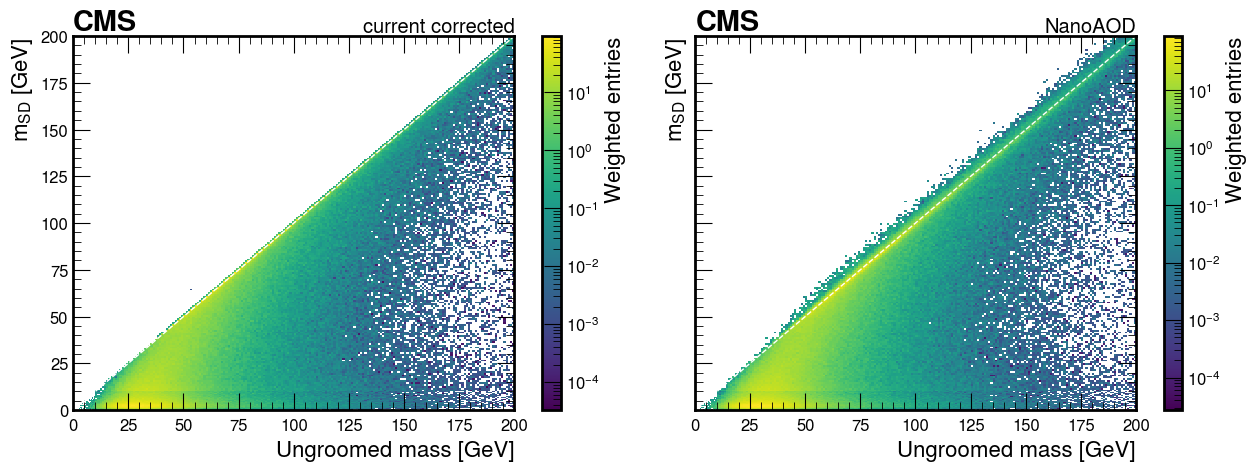

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/groomed_vs_ungroomed_mass_maps.png')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
map_specs = [
    (nt["mass"], nt["msoftdrop"], "current corrected"),
    (nt["mass_nanoaod"], nt["msoftdrop_nanoaod"], "NanoAOD"),
]
for ax, (ungroomed, groomed, title) in zip(axes, map_specs):
    mesh, _ = plot_weighted_2d(
        ax,
        ungroomed,
        groomed,
        MASS_RECO_EDGES,
        MASS_RECO_EDGES,
        finite_positive(ungroomed, groomed),
        log=True,
    )
    ax.plot(MASS_DISPLAY_RANGE, MASS_DISPLAY_RANGE, color="white", linestyle="--", linewidth=1.0)
    ax.set_xlim(*MASS_DISPLAY_RANGE)
    ax.set_ylim(*MASS_DISPLAY_RANGE)
    ax.set_xlabel("Ungroomed mass [GeV]")
    ax.set_ylabel(r"$m_{SD}$ [GeV]")
    add_cms_label(ax, rlabel=title)
    fig.colorbar(mesh, ax=ax, label="Weighted entries")
save_show(fig, "groomed_vs_ungroomed_mass_maps")


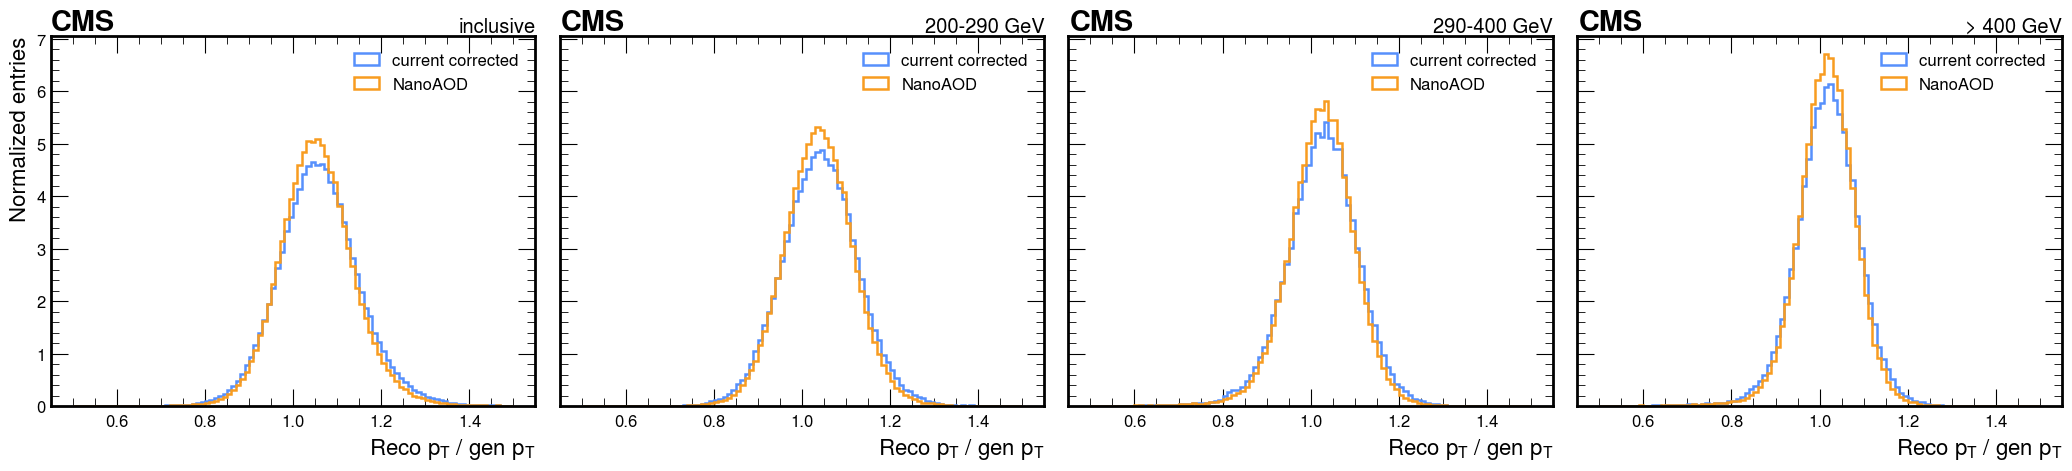

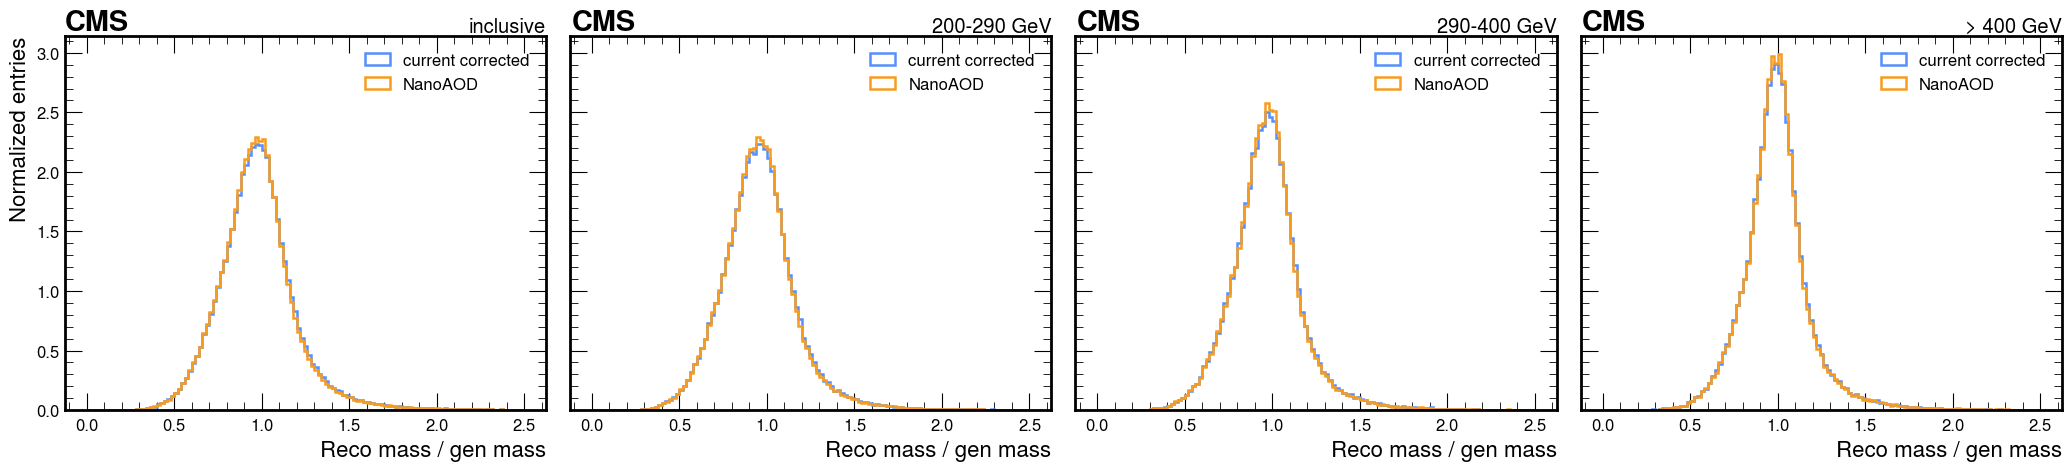

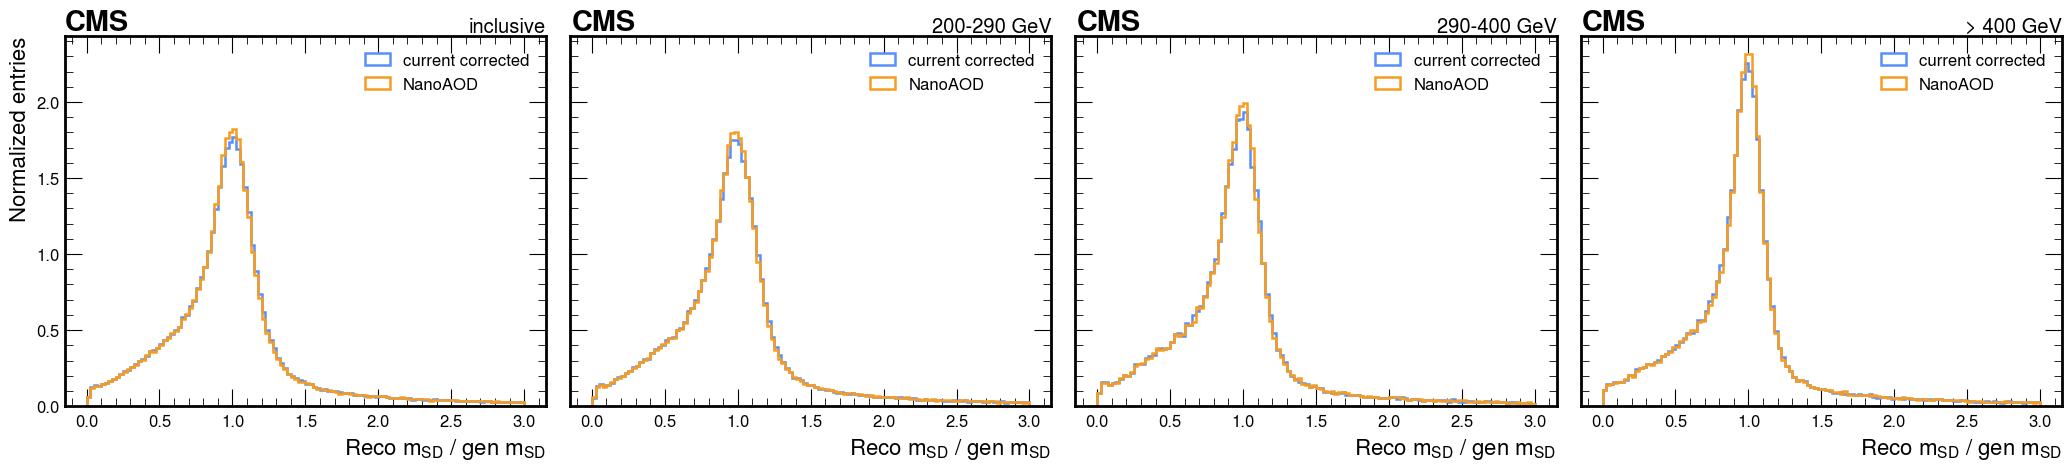

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/response_msoftdrop_over_genmsoftdrop.png')

In [ ]:
def plot_response_distribution(var, reco_corr, reco_nano, gen, bins, xlabel, name):
    corr_ratio = safe_ratio(reco_corr, gen)
    nano_ratio = safe_ratio(reco_nano, gen)
    mask = response_base & finite_positive(gen, reco_corr, reco_nano)
    fig, axes = plt.subplots(1, 4, figsize=(21, 5), sharey=True)
    hist_step(axes[0], corr_ratio, bins, mask, label="current corrected", density=True)
    hist_step(axes[0], nano_ratio, bins, mask, label="NanoAOD", density=True)
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Normalized entries")
    axes[0].legend()
    add_cms_label(axes[0], rlabel="inclusive")
    for i, ax in enumerate(axes[1:]):
        ptmask = mask & (nt["gen_pt"] >= PT_EDGES[i]) & (nt["gen_pt"] < PT_EDGES[i + 1])
        hist_step(ax, corr_ratio, bins, ptmask, label="current corrected", density=True)
        hist_step(ax, nano_ratio, bins, ptmask, label="NanoAOD", density=True)
        ax.set_xlabel(xlabel)
        ax.legend()
        add_cms_label(ax, rlabel=PT_LABELS[i])
    return save_show(fig, name)

plot_response_distribution("pt", nt["pt"], nt["pt_nanoaod"], nt["gen_pt"], np.linspace(0.5, 1.5, 101), r"Reco $p_T$ / gen $p_T$", "response_pt_over_genpt")
plot_response_distribution("mass", nt["mass"], nt["mass_nanoaod"], nt["gen_mass"], np.linspace(0.0, 2.5, 126), r"Reco mass / gen mass", "response_mass_over_genmass")
plot_response_distribution("msoftdrop", nt["msoftdrop"], nt["msoftdrop_nanoaod"], nt["gen_msoftdrop"], np.linspace(0.0, 3.0, 121), r"Reco $m_{SD}$ / gen $m_{SD}$", "response_msoftdrop_over_genmsoftdrop")


'pt'

,pt bin,source,median,half width q84-q16,q16,q84,entries
0,200-290 GeV,current corrected,1.040910,0.082310,0.958253,1.122874,222259
1,200-290 GeV,NanoAOD,1.037470,0.075397,0.961813,1.112607,222259
2,290-400 GeV,current corrected,1.027691,0.076787,0.948734,1.102309,155838
3,290-400 GeV,NanoAOD,1.025266,0.070212,0.953062,1.093486,155838
4,> 400 GeV,current corrected,1.018492,0.066228,0.951170,1.083626,274634
5,> 400 GeV,NanoAOD,1.016819,0.060418,0.955398,1.076234,274634


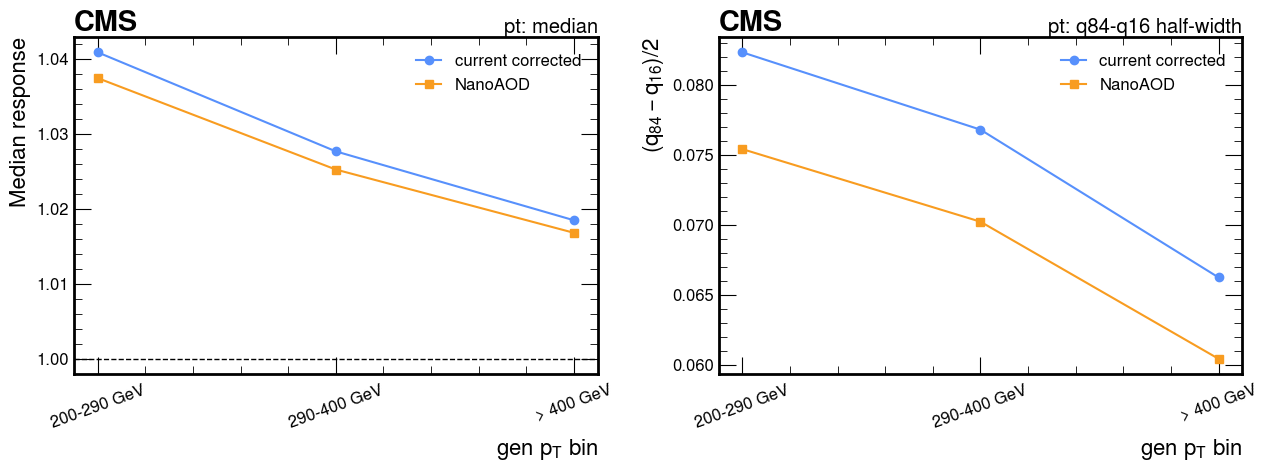

'mass'

,pt bin,source,median,half width q84-q16,q16,q84,entries
0,200-290 GeV,current corrected,0.948731,0.188456,0.759292,1.136203,222259
1,200-290 GeV,NanoAOD,0.946545,0.185069,0.759139,1.129278,222259
2,290-400 GeV,current corrected,0.964146,0.173513,0.786029,1.133055,155838
3,290-400 GeV,NanoAOD,0.962941,0.170535,0.786343,1.127413,155838
4,> 400 GeV,current corrected,0.984894,0.155690,0.827789,1.139170,274634
5,> 400 GeV,NanoAOD,0.984007,0.153313,0.828254,1.134880,274634


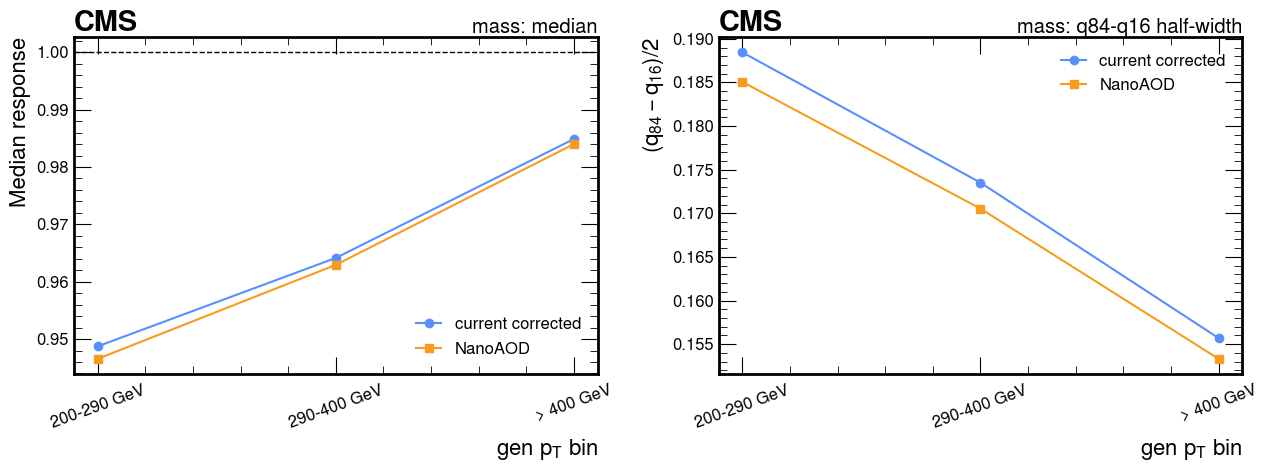

'msoftdrop'

,pt bin,source,median,half width q84-q16,q16,q84,entries
0,200-290 GeV,current corrected,0.967309,0.364732,0.610437,1.339900,222176
1,200-290 GeV,NanoAOD,0.967101,0.364987,0.612699,1.342673,222176
2,290-400 GeV,current corrected,0.961161,0.336128,0.595824,1.268079,155736
3,290-400 GeV,NanoAOD,0.961991,0.336144,0.598242,1.270529,155736
4,> 400 GeV,current corrected,0.967067,0.330542,0.613726,1.274810,274264
5,> 400 GeV,NanoAOD,0.969584,0.330691,0.615942,1.277323,274264


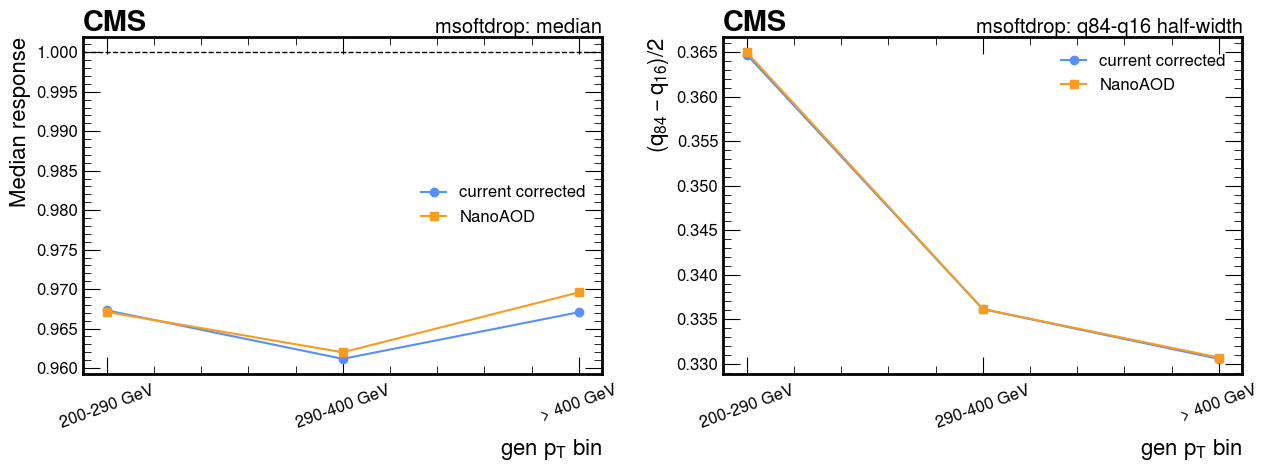

In [ ]:
def response_summary(reco_corr, reco_nano, gen):
    rows = []
    for i, label in enumerate(PT_LABELS):
        base = response_base & (nt["gen_pt"] >= PT_EDGES[i]) & (nt["gen_pt"] < PT_EDGES[i + 1]) & finite_positive(reco_corr, reco_nano, gen)
        for source, reco in [("current corrected", reco_corr), ("NanoAOD", reco_nano)]:
            ratio = safe_ratio(reco, gen)
            q16, q50, q84 = weighted_quantile(ratio[base], [0.16, 0.50, 0.84], weights_for(base))
            rows.append({
                "pt bin": label,
                "source": source,
                "median": q50,
                "half width q84-q16": 0.5 * (q84 - q16),
                "q16": q16,
                "q84": q84,
                "entries": int(base.sum()),
            })
    return pd.DataFrame(rows)

summaries = {
    "pt": response_summary(nt["pt"], nt["pt_nanoaod"], nt["gen_pt"]),
    "mass": response_summary(nt["mass"], nt["mass_nanoaod"], nt["gen_mass"]),
    "msoftdrop": response_summary(nt["msoftdrop"], nt["msoftdrop_nanoaod"], nt["gen_msoftdrop"]),
}

for name, table in summaries.items():
    display(name, table)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
    x = np.arange(len(PT_LABELS))
    for source, marker in [("current corrected", "o"), ("NanoAOD", "s")]:
        sub = table[table["source"] == source].set_index("pt bin").loc[PT_LABELS]
        axes[0].plot(x, sub["median"], marker=marker, label=source)
        axes[1].plot(x, sub["half width q84-q16"], marker=marker, label=source)
    axes[0].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
    axes[0].set_ylabel("Median response")
    axes[1].set_ylabel(r"$(q_{84} - q_{16}) / 2$")
    panel_rlabels = [f"{name}: median", f"{name}: q84-q16 half-width"]
    for ax, rlabel in zip(axes, panel_rlabels):
        ax.set_xticks(x, PT_LABELS, rotation=20)
        ax.set_xlabel(r"gen $p_T$ bin")
        ax.legend()
        add_cms_label(ax, rlabel=rlabel)
    save_show(fig, f"robust_resolution_summary_{name}")


In [ ]:
def flat_indices(pt_values, mass_values, pt_edges, mass_edges):
    ipt = np.searchsorted(pt_edges, pt_values, side="right") - 1
    imass = np.searchsorted(mass_edges, mass_values, side="right") - 1
    n_pt = len(pt_edges) - 1
    n_mass = len(mass_edges) - 1
    valid = (ipt >= 0) & (ipt < n_pt) & (imass >= 0) & (imass < n_mass)
    idx = ipt * n_mass + imass
    return idx, valid, n_pt * n_mass, n_mass


def make_flat_response(reco_pt, reco_mass, gen_mass, reco_mass_edges=RESPONSE_MASS_RECO_EDGES, gen_mass_edges=RESPONSE_MASS_GEN_EDGES):
    base = response_base & finite_positive(reco_pt, reco_mass, nt["gen_pt"], gen_mass)
    reco_idx, reco_valid, n_reco, n_reco_mass = flat_indices(reco_pt, reco_mass, PT_EDGES, reco_mass_edges)
    gen_idx, gen_valid, n_gen, n_gen_mass = flat_indices(nt["gen_pt"], gen_mass, PT_EDGES, gen_mass_edges)
    mask = base & reco_valid & gen_valid
    matrix, _, _ = np.histogram2d(
        reco_idx[mask],
        gen_idx[mask],
        bins=[np.arange(n_reco + 1) - 0.5, np.arange(n_gen + 1) - 0.5],
        weights=weights_for(mask),
    )
    return matrix, n_reco_mass, n_gen_mass


def row_normalize(matrix):
    rows = matrix.sum(axis=1, keepdims=True)
    return np.divide(matrix, rows, out=np.zeros_like(matrix, dtype=float), where=rows > 0)


def draw_pt_boundaries(ax, n_reco_mass, n_gen_mass):
    for i in range(1, len(PT_EDGES) - 1):
        ax.axhline(i * n_reco_mass - 0.5, color="white", alpha=0.45, linewidth=0.8)
        ax.axvline(i * n_gen_mass - 0.5, color="white", alpha=0.45, linewidth=0.8)


def plot_flat_matrix(kind, corr_matrix, nano_matrix, n_reco_mass, n_gen_mass, name):
    corr_norm = row_normalize(corr_matrix)
    nano_norm = row_normalize(nano_matrix)
    diff = corr_norm - nano_norm
    ratio = np.divide(
        corr_norm,
        nano_norm,
        out=np.full_like(corr_norm, np.nan, dtype=float),
        where=nano_norm > 0,
    )
    ratio = np.ma.masked_invalid(ratio)

    fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharex=True, sharey=True)
    panels = [
        (corr_norm, "current corrected", "viridis", None, "row-normalized fraction", True),
        (nano_norm, "NanoAOD", "viridis", None, "row-normalized fraction", True),
        (diff, "current - NanoAOD", "coolwarm", TwoSlopeNorm(vmin=-0.25, vcenter=0.0, vmax=0.25), "difference", False),
        (ratio, "current / NanoAOD", "coolwarm", TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5), "ratio", False),
    ]
    for ax, (values, title, cmap, norm, cbar_label, mask_positive) in zip(axes, panels):
        if norm is None:
            show_values = np.ma.masked_where(values <= 0, values)
            image = ax.imshow(show_values, origin="lower", aspect="auto", cmap=cmap, vmin=0.0, vmax=max(0.2, np.nanmax(values)))
        else:
            show_values = np.ma.masked_where(values <= 0, values) if mask_positive else values
            image = ax.imshow(show_values, origin="lower", aspect="auto", cmap=cmap, norm=norm)
        draw_pt_boundaries(ax, n_reco_mass, n_gen_mass)
        ax.set_xlabel("flattened gen pT-mass bin")
        ax.set_ylabel("flattened reco pT-mass bin")
        fig.colorbar(image, ax=ax, label=cbar_label)
        add_cms_label(ax, rlabel=title)
    fig.text(0.5, 0.01, f"Flattened {kind} response matrix", ha="center", va="bottom", fontsize=13)
    return save_show(fig, name)


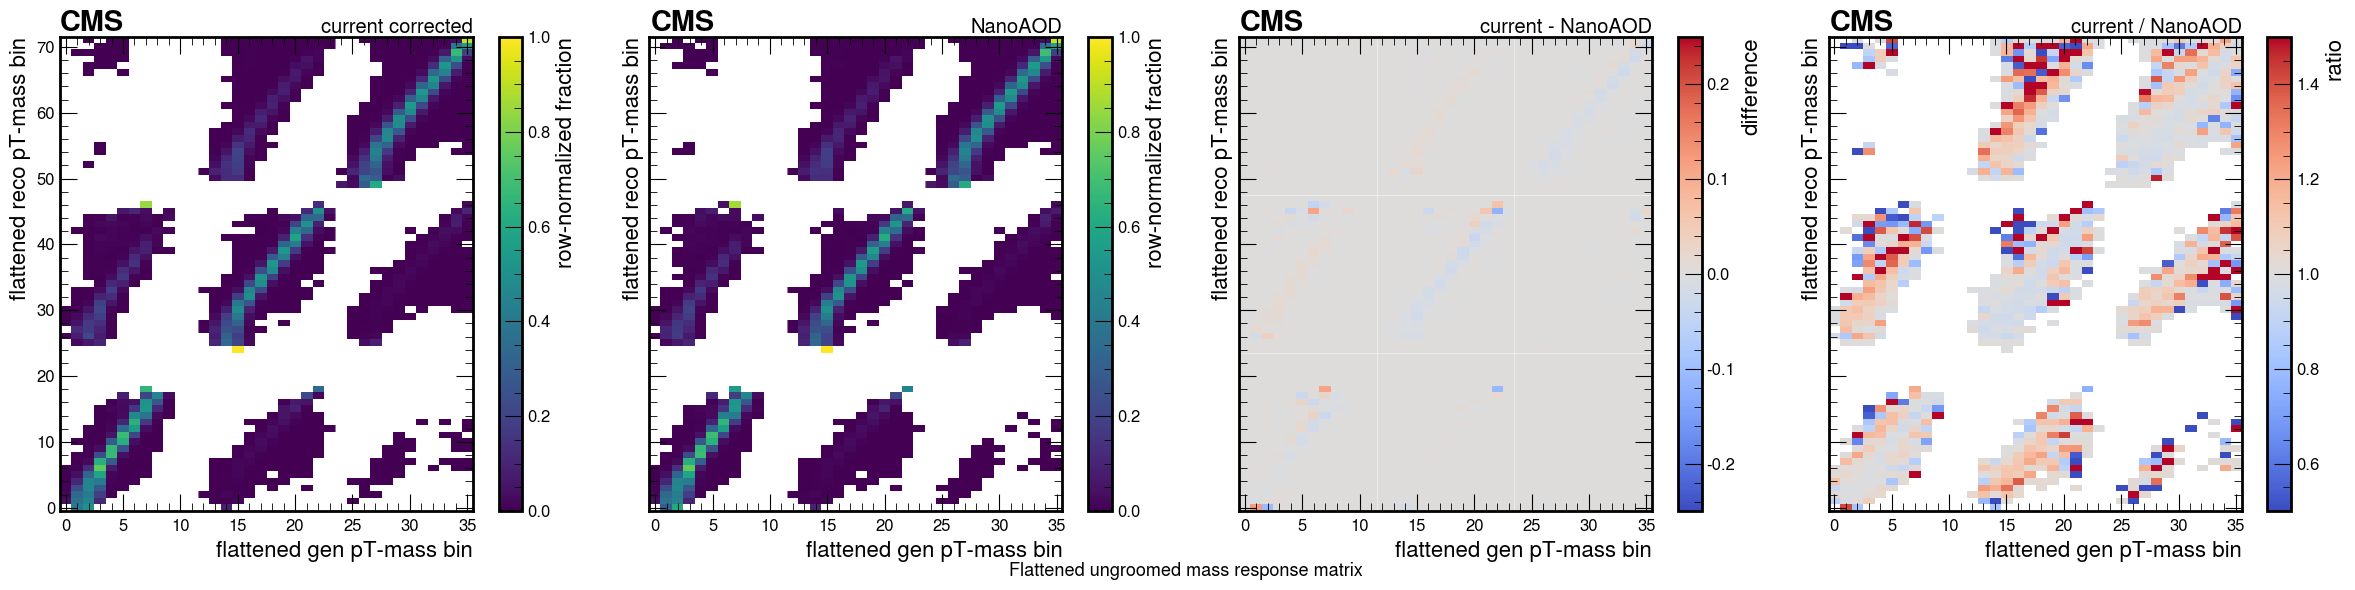

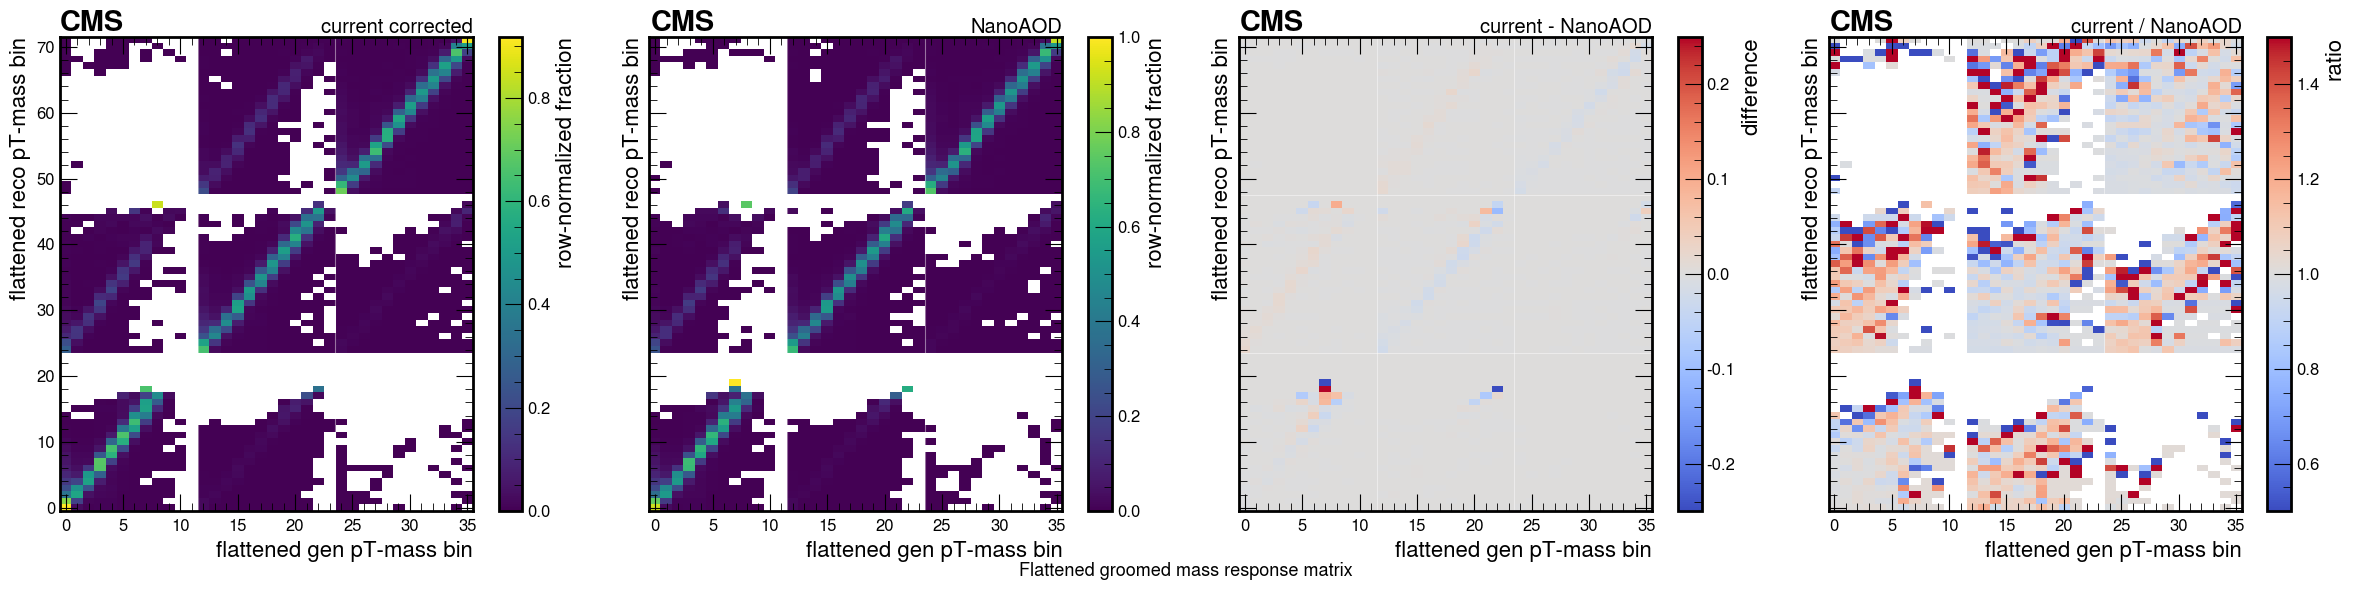

In [ ]:
flat_specs = [
    ("ungroomed mass", nt["mass"], nt["mass_nanoaod"], nt["gen_mass"], "flat_response_ungroomed_mass"),
    ("groomed mass", nt["msoftdrop"], nt["msoftdrop_nanoaod"], nt["gen_msoftdrop"], "flat_response_groomed_mass"),
]

for title, corr_mass, nano_mass, gen_mass, name in flat_specs:
    corr_matrix, n_reco_mass, n_gen_mass = make_flat_response(nt["pt"], corr_mass, gen_mass)
    nano_matrix, _, _ = make_flat_response(nt["pt_nanoaod"], nano_mass, gen_mass)
    plot_flat_matrix(title, corr_matrix, nano_matrix, n_reco_mass, n_gen_mass, name)


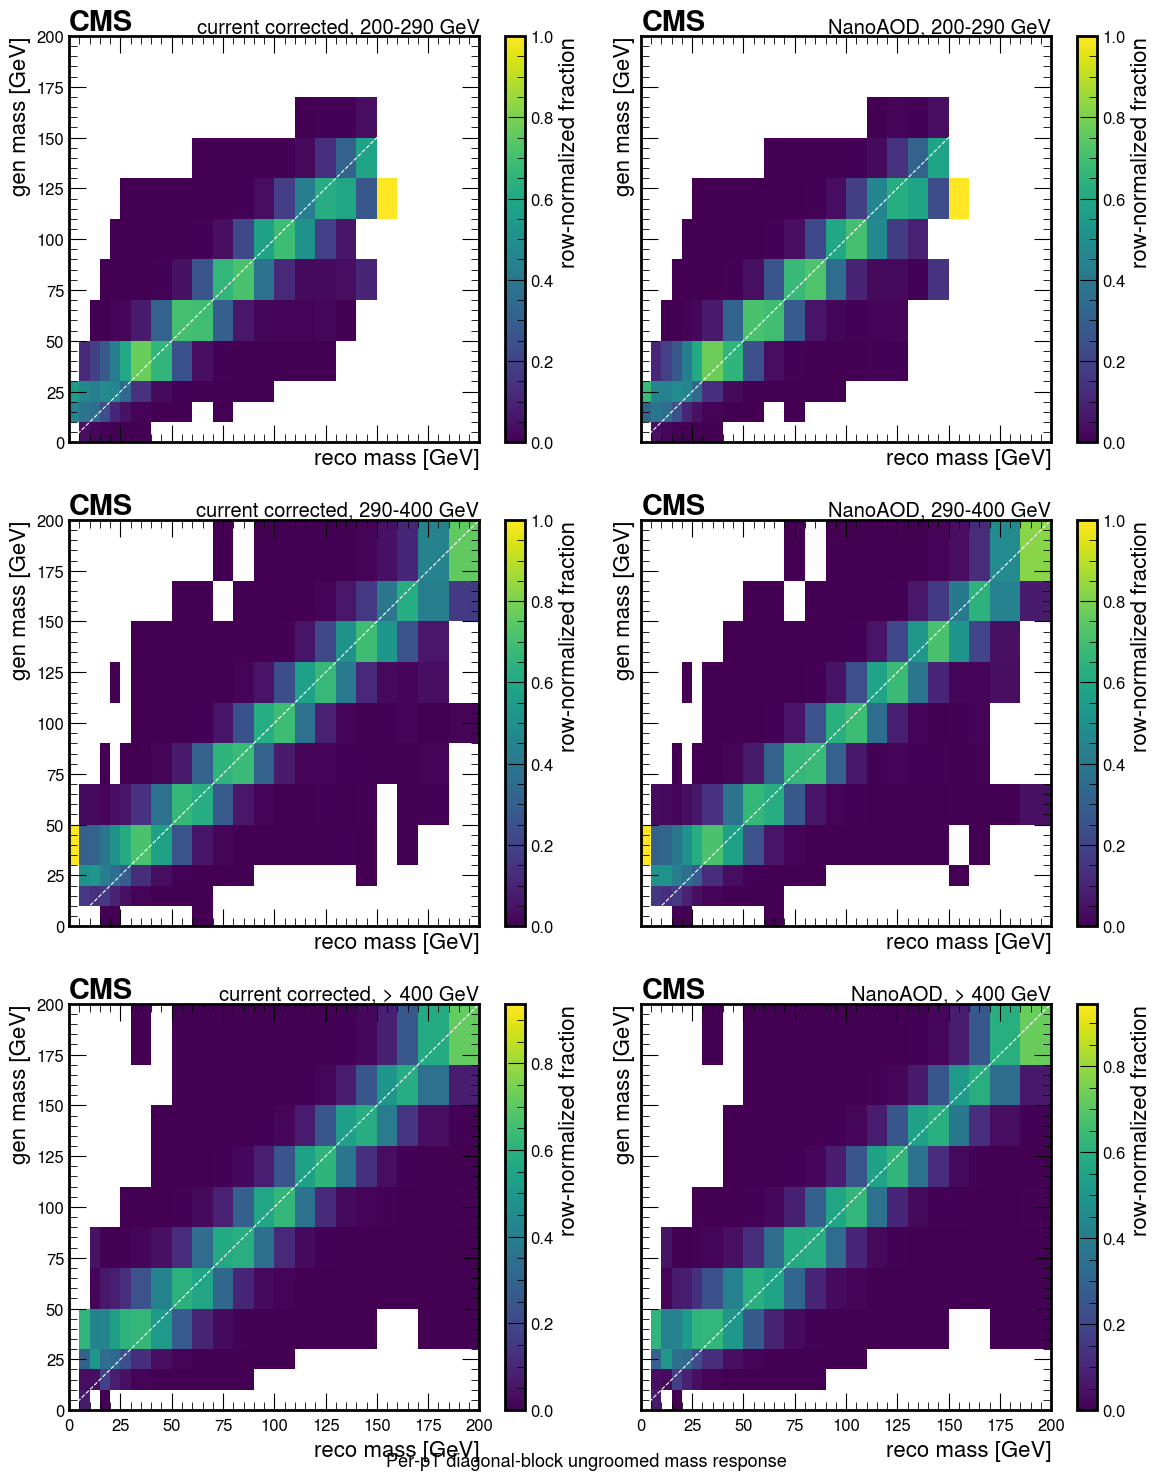

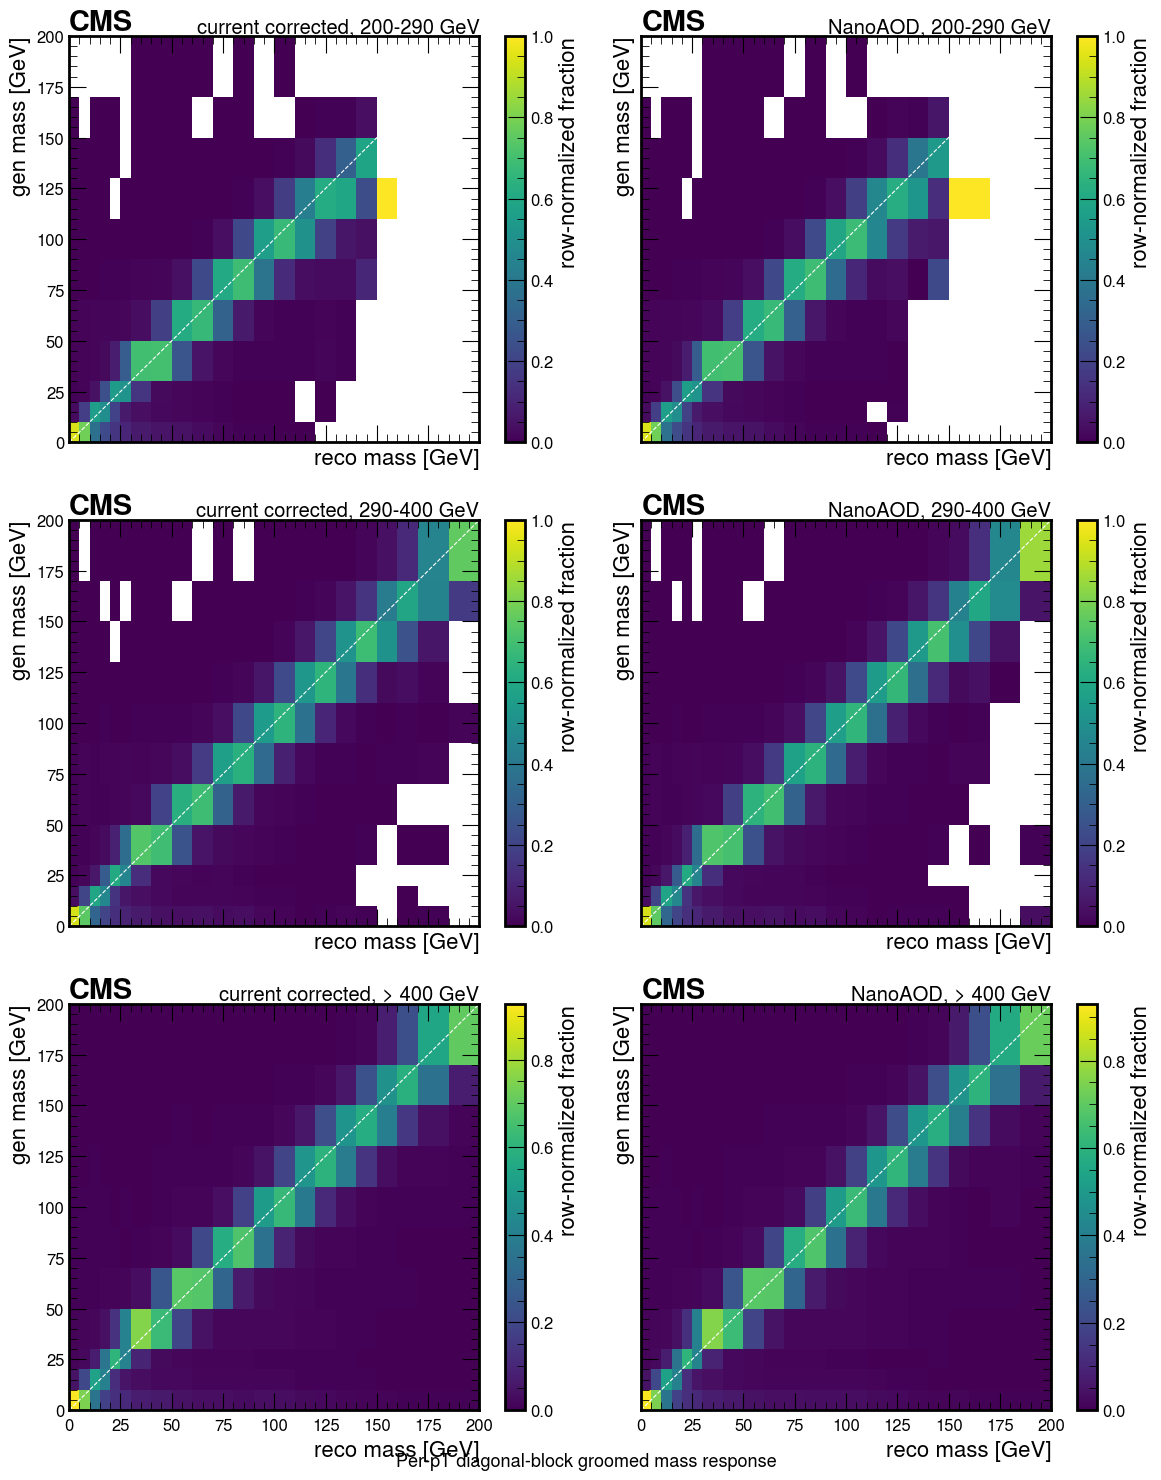

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/per_pt_response_groomed_mass.png')

In [ ]:
def mass_matrix(reco_pt, reco_mass, gen_mass, pt_bin_index, mass_reco_edges=RESPONSE_MASS_RECO_EDGES, mass_gen_edges=RESPONSE_MASS_GEN_EDGES):
    pt_mask = (
        (nt["gen_pt"] >= PT_EDGES[pt_bin_index])
        & (nt["gen_pt"] < PT_EDGES[pt_bin_index + 1])
        & (reco_pt >= PT_EDGES[pt_bin_index])
        & (reco_pt < PT_EDGES[pt_bin_index + 1])
    )
    mask = response_base & pt_mask & finite_positive(reco_pt, reco_mass, nt["gen_pt"], gen_mass)
    matrix, _, _ = np.histogram2d(reco_mass[mask], gen_mass[mask], bins=[mass_reco_edges, mass_gen_edges], weights=weights_for(mask))
    return matrix


def plot_per_pt_mass_response(kind, corr_reco_mass, nano_reco_mass, gen_mass, name):
    fig, axes = plt.subplots(len(PT_LABELS), 2, figsize=(12, 15), sharex=True, sharey=True)
    for i, label in enumerate(PT_LABELS):
        matrices = [
            (mass_matrix(nt["pt"], corr_reco_mass, gen_mass, i), "current corrected"),
            (mass_matrix(nt["pt_nanoaod"], nano_reco_mass, gen_mass, i), "NanoAOD"),
        ]
        for ax, (matrix, source) in zip(axes[i], matrices):
            normed = row_normalize(matrix)
            values = np.ma.masked_where(normed.T <= 0, normed.T)
            mesh = ax.pcolormesh(RESPONSE_MASS_RECO_EDGES, RESPONSE_MASS_GEN_EDGES, values, cmap="viridis", vmin=0, vmax=max(0.2, np.nanmax(normed) if np.isfinite(normed).any() else 0.2), shading="auto")
            ax.plot(MASS_DISPLAY_RANGE, MASS_DISPLAY_RANGE, color="white", linestyle="--", linewidth=0.8)
            ax.set_xlim(*MASS_DISPLAY_RANGE)
            ax.set_ylim(*MASS_DISPLAY_RANGE)
            ax.set_xlabel("reco mass [GeV]")
            ax.set_ylabel("gen mass [GeV]")
            fig.colorbar(mesh, ax=ax, label="row-normalized fraction")
            add_cms_label(ax, rlabel=f"{source}, {label}")
    fig.text(0.5, 0.01, f"Per-pT diagonal-block {kind} response", ha="center", va="bottom", fontsize=13)
    return save_show(fig, name)

plot_per_pt_mass_response("ungroomed mass", nt["mass"], nt["mass_nanoaod"], nt["gen_mass"], "per_pt_response_ungroomed_mass")
plot_per_pt_mass_response("groomed mass", nt["msoftdrop"], nt["msoftdrop_nanoaod"], nt["gen_msoftdrop"], "per_pt_response_groomed_mass")


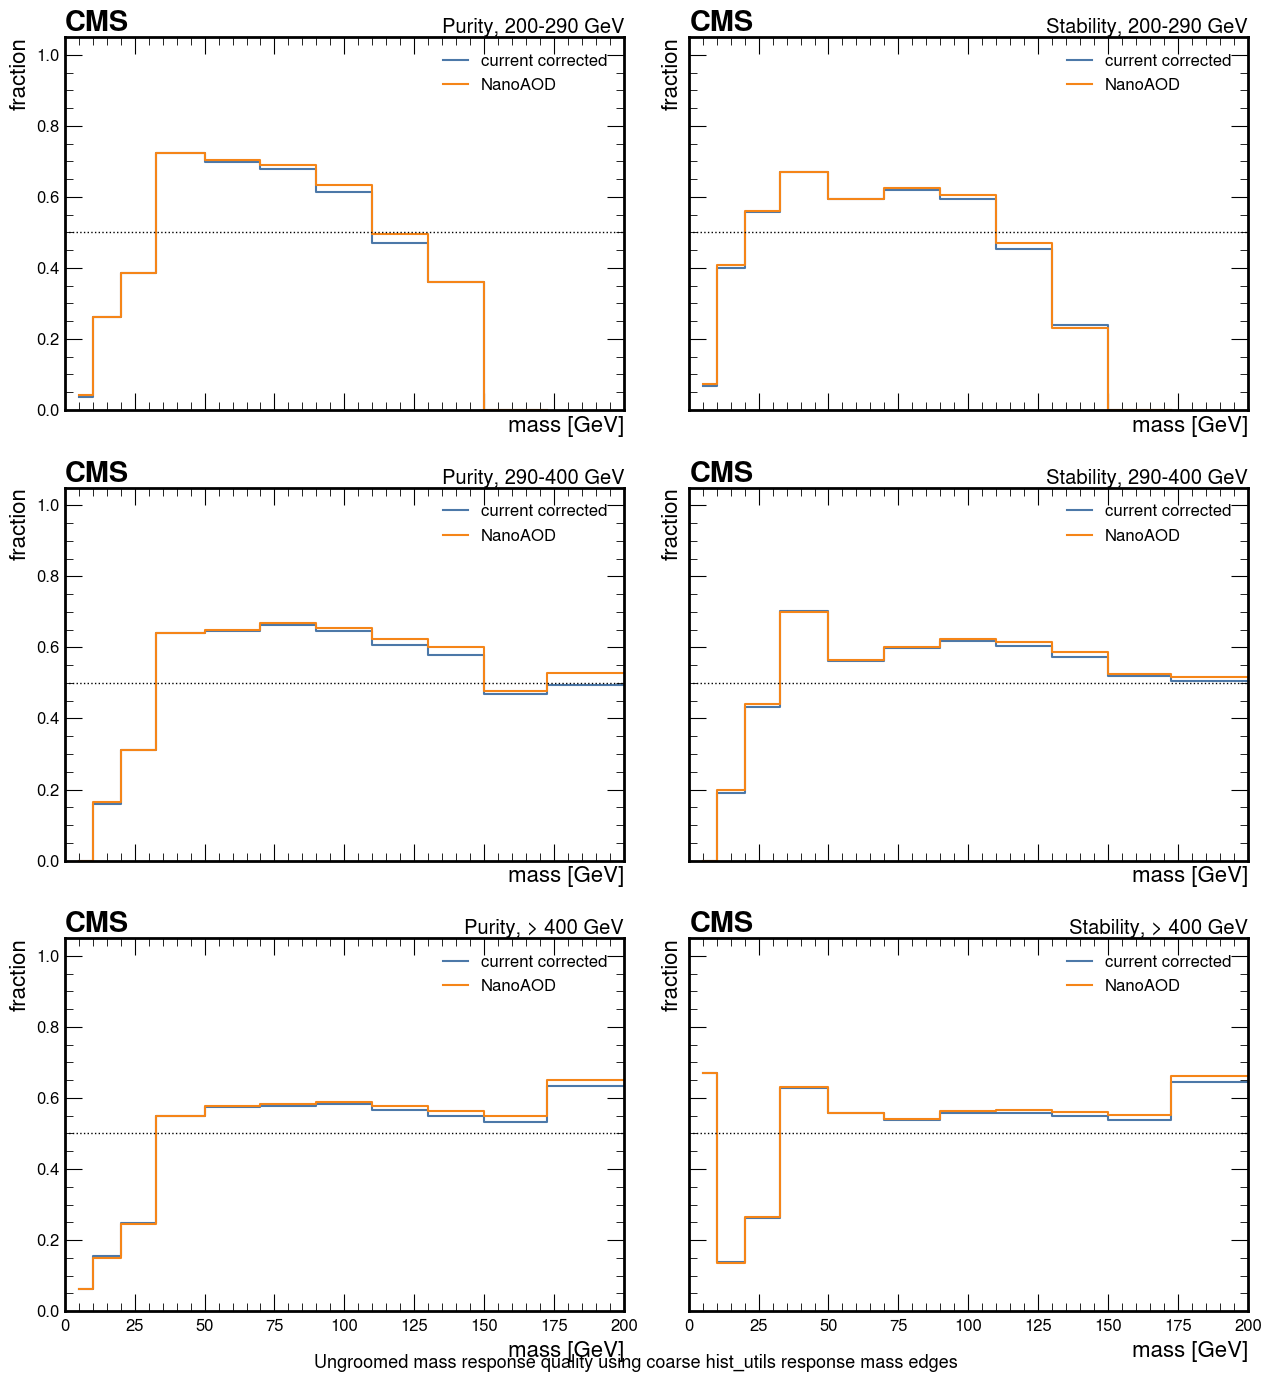

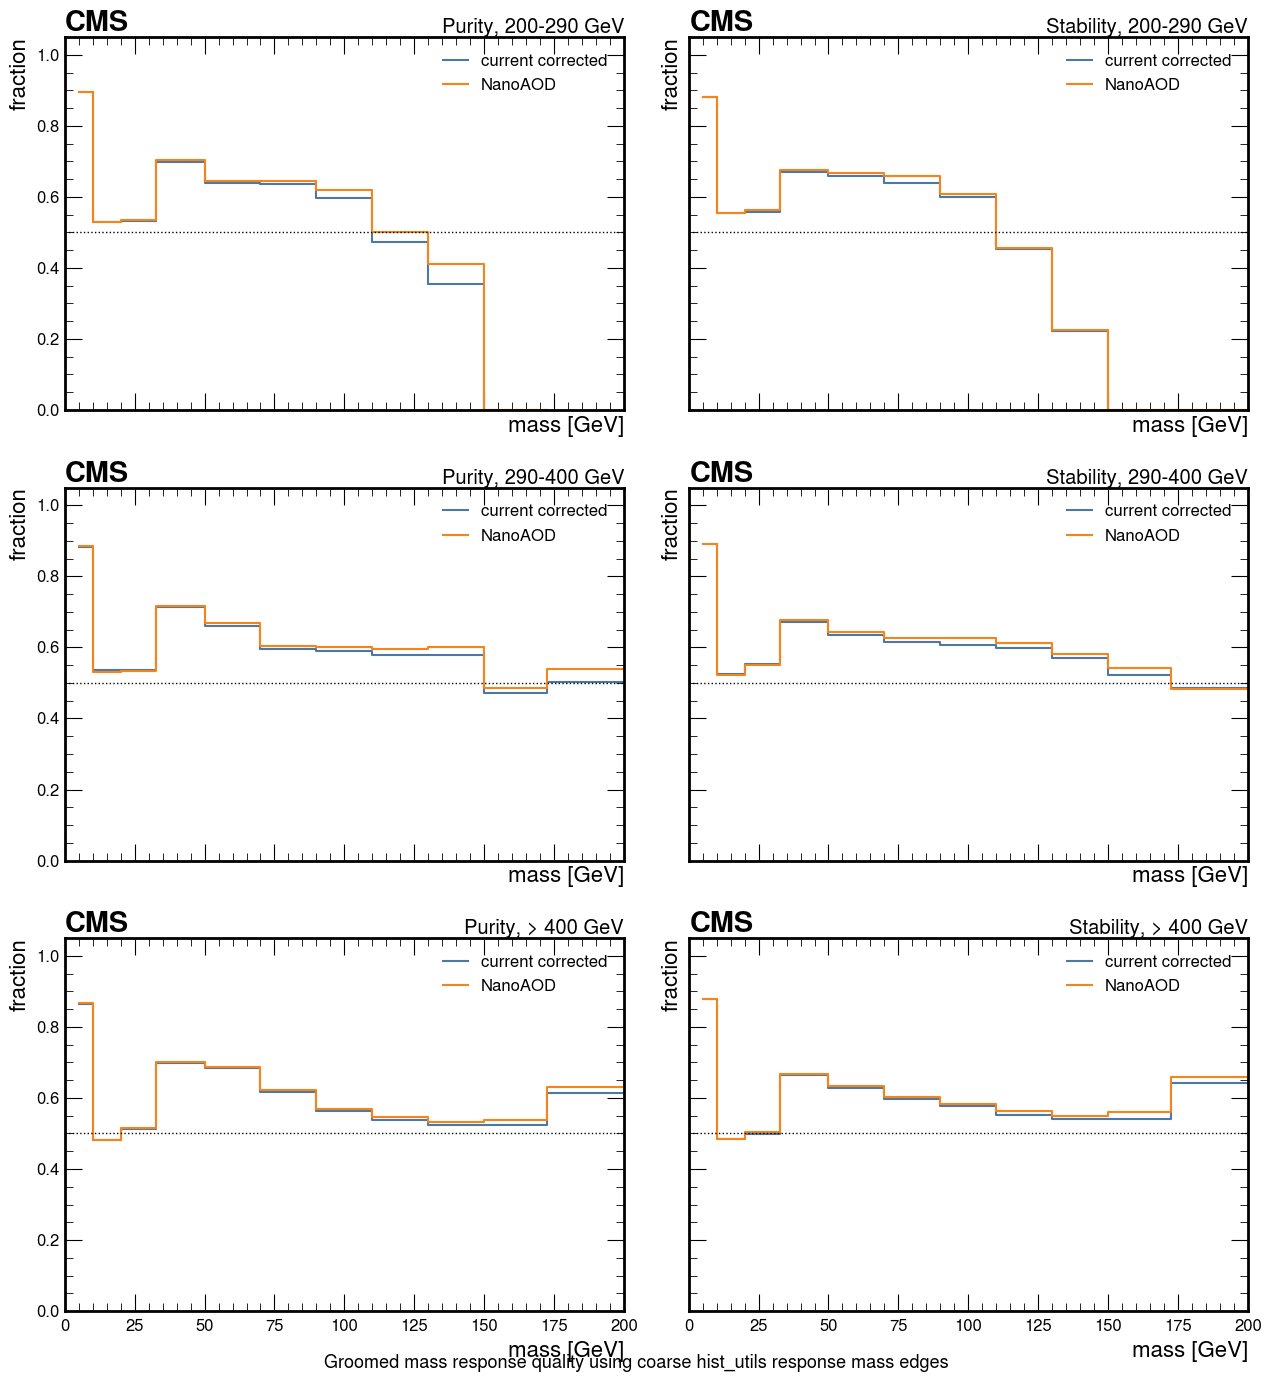

PosixPath('/mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots/purity_stability_groomed_mass.png')

In [ ]:
def same_edge_mass_response(reco_pt, reco_mass, gen_mass, pt_bin_index):
    pt_mask = (
        (nt["gen_pt"] >= PT_EDGES[pt_bin_index])
        & (nt["gen_pt"] < PT_EDGES[pt_bin_index + 1])
        & (reco_pt >= PT_EDGES[pt_bin_index])
        & (reco_pt < PT_EDGES[pt_bin_index + 1])
    )
    mask = response_base & pt_mask & finite_positive(reco_pt, reco_mass, nt["gen_pt"], gen_mass)
    matrix, _, _ = np.histogram2d(reco_mass[mask], gen_mass[mask], bins=[PURITY_MASS_EDGES, PURITY_MASS_EDGES], weights=weights_for(mask))
    return matrix


def purity_stability(matrix):
    diag = np.diag(matrix)
    row_sum = matrix.sum(axis=1)
    col_sum = matrix.sum(axis=0)
    purity = np.divide(diag, row_sum, out=np.full_like(diag, np.nan, dtype=float), where=row_sum > 0)
    stability = np.divide(diag, col_sum, out=np.full_like(diag, np.nan, dtype=float), where=col_sum > 0)
    return purity, stability


def plot_purity_stability(kind, corr_reco_mass, nano_reco_mass, gen_mass, name):
    centers = 0.5 * (PURITY_MASS_EDGES[:-1] + PURITY_MASS_EDGES[1:])
    fig, axes = plt.subplots(len(PT_LABELS), 2, figsize=(13, 14), sharex=True, sharey=True)
    for i, label in enumerate(PT_LABELS):
        for source, reco_pt, reco_mass, color in [
            ("current corrected", nt["pt"], corr_reco_mass, "#4C78A8"),
            ("NanoAOD", nt["pt_nanoaod"], nano_reco_mass, "#F58518"),
        ]:
            matrix = same_edge_mass_response(reco_pt, reco_mass, gen_mass, i)
            purity, stability = purity_stability(matrix)
            axes[i, 0].step(centers, purity, where="mid", label=source, color=color, linewidth=1.5)
            axes[i, 1].step(centers, stability, where="mid", label=source, color=color, linewidth=1.5)
        
        for j, ax in enumerate(axes[i]):
            ax.axhline(0.5, color="black", linestyle=":", linewidth=1.0)
            ax.set_xlim(*MASS_DISPLAY_RANGE)
            ax.set_ylim(0, 1.05)
            ax.set_xlabel("mass [GeV]")
            ax.set_ylabel("fraction")
            ax.legend()
            add_cms_label(ax, rlabel=f"{'Purity' if j == 0 else 'Stability'}, {label}")
    fig.text(0.5, 0.01, f"{kind} response quality using coarse hist_utils response mass edges", ha="center", va="bottom", fontsize=13)
    return save_show(fig, name)

plot_purity_stability("Ungroomed mass", nt["mass"], nt["mass_nanoaod"], nt["gen_mass"], "purity_stability_ungroomed_mass")
plot_purity_stability("Groomed mass", nt["msoftdrop"], nt["msoftdrop_nanoaod"], nt["gen_msoftdrop"], "purity_stability_groomed_mass")


In [ ]:
saved = pd.DataFrame({"figure": [p.name for p in _SAVED_FIGURES], "path": [str(p) for p in _SAVED_FIGURES]})
display(saved)
print(f"Saved {len(_SAVED_FIGURES)} figures to {PLOT_DIR}")


,figure,path
0,sanity_flags_and_match_dr.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
1,datamc_reco_pt_nanoaod_vs_corrected.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
2,datamc_ungroomed_mass_nanoaod_vs_corrected.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
3,datamc_groomed_mass_nanoaod_vs_corrected.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
4,corrected_over_nanoaod_ratios.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
5,mass_scale_factor_comparison.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
6,groomed_over_ungroomed_mass_ratio_overlay.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
7,groomed_vs_ungroomed_mass_maps.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
8,response_pt_over_genpt.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...
9,response_mass_over_genmass.png,/mnt/extra/wsLinux/zjet_corrections/outputs/ma...


Saved 20 figures to /mnt/extra/wsLinux/zjet_corrections/outputs/mass_diagnostic_ntuple_plots
